# [DL] Neural Networks

### *Instructions:*
- **과제 명세서를 읽어주시고 코드 작성을 해주시길 바랍니다**</span> 
- **명시된 step을 따라가며 전체적인 학습 방법을 숙지합니다**</span>
- (**첫 번째 cell 결과로 나온 시간을 기준으로 채점을 하겠습니다**</span>).



In [1]:
import datetime
print("This code is run at " + str(datetime.datetime.now()))

This code is run at 2026-07-27 01:06:24.751754


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from mlp import MultiLayerPerceptron
import utils

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

## Problem

Mutilayer Perceptron(```class MutiLayerPerceptron```)으로 간단한 Binary classification task를 진행해봅시다.

> 1. **Dataset**
>> $\texttt{moon}$ dataset

> 2. **Network architecture**
$$
H_1=XW_1+b_1,\qquad z_1=\mathrm{ReLU}(H_1)
$$

$$
H_2=z_1W_2+b_2,\qquad z_2=\mathrm{LeakyReLU}(H_2)
$$

$$
H_3=z_2W_3+b_3,\qquad z_3=\tanh(H_3+H_1)
$$

$$
H_4=z_3W_4+b_4,\qquad \hat y=\sigma(H_4)
$$
 > $ReLU$ $=\max(0,x)$ 
 
 > $LeakyReLU(H_2)$ $=\max(0.01x,x)$ 

 
 > **$W$** and **$b$** 는 각각 weights와 bias.    
 > **weight 초기화**: Standard normal ($\texttt{np.random.randn}$. 사용)  
 > **bias 초기화(intercept)**: 0     
 > **Input size**: 2  
 > **The first hidden layer size**: 10  
 > **The second hidden layer size**: 10  
 > **Output size**: 1   
 > **Regularization parameter $\lambda$**: 0.001  
 > **Loss function**: Binary cross entropy loss (or equivently log loss).  
 > **Total loss** : 
 > $L_{total} = \sum_{i=1}^N{ (-y^{(i)}\log \hat{y}^{(i)} -(1-y^{(i)})\log(1-\hat{y}^{(i)})) } +  \lambda \|W\|^2 $   
 > **Optimization**: Gradient descent  
 > **Learning rate** = 0.0001  
 > **Number of epochs** = 50000  
 > $y$는 정답, $\hat{y}$는 예측값이고 0부터 1사이에 존재한다.  

### STEP 1. 데이터 준비

비교 실험을 위해 train/validation set을 분리합니다.

STEP 1: Load data


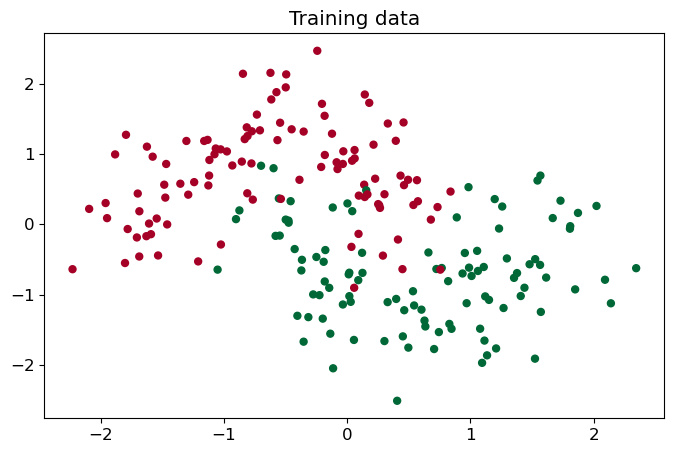

train: (210, 2) validation: (90, 2)


In [3]:
print("STEP 1: Load data")

# Load data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Visualize data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, cmap=plt.cm.RdYlGn)
plt.title("Training data")
plt.show()

print("train:", X_train.shape, "validation:", X_val.shape)

## STEP 2. 기본 모델 학습

`mlp.py`의 TODO를 모두 구현한 뒤 아래 셀을 실행하세요.

STEP 2: Train the model
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910
[bgd] epoch=600, train_loss=53.0578, train_acc=0.924
[bgd] epoch=700, train_loss=49.0516, train_acc=0.929
[bgd] epoch=800, train_loss=46.2263, train_acc=0.933
[bgd] epoch=900, train_loss=43.9536, train_acc=0.938
[bgd] epoch=1000, train_loss=41.9957, train_acc=0.938
[bgd] epoch=1100, train_loss=40.2426, train_acc=0.943
[bgd] epoch=1200, train_loss=38.6305, train_acc=0.948
[bgd] epoch=1300, train_loss=37.1382, train_acc=0.952
[bgd] epoch=1400, train_loss=35.8192, train_acc=0.952
[bgd] epoch=1500, train_loss=34.6701, train_acc=0.957
[bgd] epoch=1600, train_loss=33.6805, train_acc=0.957
[bgd] epoch=1700, train_loss=32.7792, train_acc=0.957
[bgd] epoch=1800, train_loss=31.9337, train_acc=0.957
[bgd] epoch=1

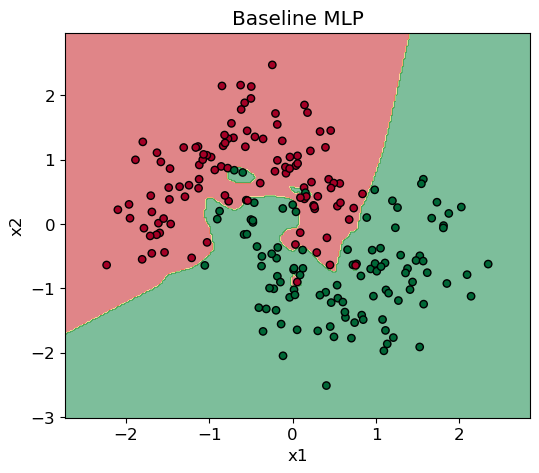

In [4]:
print("STEP 2: Train the model")
# random seed
np.random.seed(0)

# Hyperparameters
nn_input_dim = 2
nn_output_dim = 1
nn_hdim1 = 10
nn_hdim2 = 10
nn_hdim3 = 10
lr = 0.0001 
L2_norm = 0.001
epoch = 50000

model = MultiLayerPerceptron(nn_input_dim, nn_hdim1, nn_hdim2, nn_hdim3, nn_output_dim, init="random")
stats = model.train(X_train, y_train, learning_rate=lr, L2_norm=L2_norm, epoch=epoch, print_loss=True)
utils.plot_decision_boundary(model, X_train, y_train, "Baseline MLP")

## STEP 3. BGD vs SGD vs Mini-batch GD

아래 조건은 세 방법에서 동일하게 고정합니다.

- 동일한 model architecture 및 초기 weight seed
- 동일한 learning rate
- 동일한 epoch 수
- 동일한 train/validation data

In [5]:
print("STEP 3: Compare BGD, SGD, and Mini-batch GD")

# 세 실험에서는 optimizer와 batch_size만 변경합니다.

optimizer_settings = {
    "BGD": {
        "optimizer": "bgd",
        "batch_size": None,
    },
    "SGD": {
        "optimizer": "sgd",
        "batch_size": 1,
    },
    "Mini-batch": {
        "optimizer": "minibatch",
        "batch_size": 32,
    },
}

models = {}
histories = {}

for name, setting in optimizer_settings.items():

    model = MultiLayerPerceptron(
        nn_input_dim,
        nn_hdim1,
        nn_hdim2,
        nn_hdim3,
        nn_output_dim,
        init="random",
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=lr,
        L2_norm=L2_norm,
        epoch=10000, #step 3에서는 epoch 줄여서 실행
        optimizer=setting["optimizer"],
        batch_size=setting["batch_size"],
        seed=0,
        eval_every=5,
        print_loss=True,
    )

    models[name] = model
    histories[name] = history

utils.result_table(histories)

STEP 3: Compare BGD, SGD, and Mini-batch GD
[bgd] epoch=50, train_loss=100.8804, train_acc=0.800, val_loss=43.3482, val_acc=0.789
[bgd] epoch=100, train_loss=86.4001, train_acc=0.810, val_loss=38.0664, val_acc=0.800
[bgd] epoch=150, train_loss=80.2071, train_acc=0.814, val_loss=36.1744, val_acc=0.800
[bgd] epoch=200, train_loss=75.9894, train_acc=0.871, val_loss=34.9003, val_acc=0.833
[bgd] epoch=250, train_loss=72.4697, train_acc=0.890, val_loss=33.6763, val_acc=0.867
[bgd] epoch=300, train_loss=69.5096, train_acc=0.895, val_loss=32.5396, val_acc=0.867
[bgd] epoch=350, train_loss=66.8955, train_acc=0.895, val_loss=31.6341, val_acc=0.878
[bgd] epoch=400, train_loss=64.4193, train_acc=0.914, val_loss=30.8550, val_acc=0.878
[bgd] epoch=450, train_loss=61.8250, train_acc=0.914, val_loss=30.0760, val_acc=0.878
[bgd] epoch=500, train_loss=58.7299, train_acc=0.910, val_loss=29.2237, val_acc=0.878
[bgd] epoch=550, train_loss=55.7964, train_acc=0.910, val_loss=28.2835, val_acc=0.878
[bgd] epoc

,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,BGD,10000,12.223603,13.598985,0.971429,29.455395,0.922222
1,SGD,2100000,817.809270,21.512876,0.966667,23.157484,0.900000
2,Mini-batch,70000,13.562809,13.841743,0.971429,29.232358,0.922222


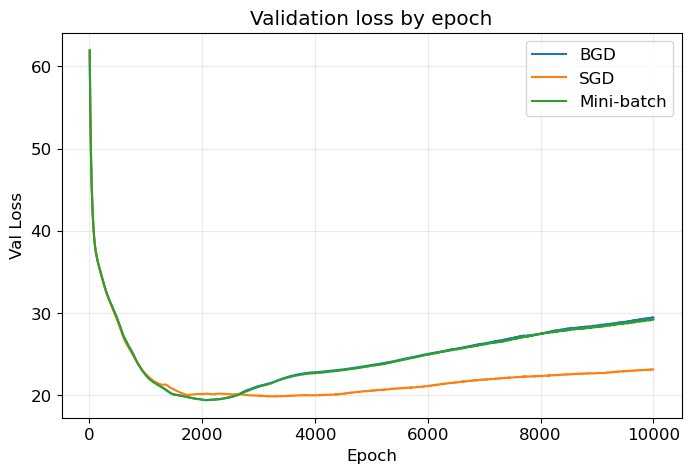

In [6]:
utils.plot_optimizer_histories(
    histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

## STEP 4. 하이퍼파라미터 탐색

BGD, SGD, Mini-batch GD 중 **하나를 선택**하여 여러 하이퍼파라미터 조합을 자유롭게 실험해봅시다.

변경 가능한 예시:

- learning rate
- epoch
- hidden dimension
- batch size
- L2 regularization strength
- initialization seed

최소 3개 이상의 조합을 시도하고, 아래에 기록하시면 됩니다.

In [7]:
print("STEP 4: Hyperparameter Tuning")

# STEP 3 결과를 바탕으로 속도와 안정성의 균형이 좋은
# Mini-batch Gradient Descent를 선택하였다.
chosen_optimizer = "minibatch"

# learning rate, hidden dimension, batch size,
# L2 regularization의 영향을 비교하기 위한 세 가지 조합
trial_configs = [
    {
        "name": "baseline_setting",
        "lr": 1e-3,
        "epoch": 1000,
        "hidden": 10,
        "batch_size": 32,
        "l2": 0.0,
        "seed": 0,
    },
    {
        "name": "larger_learning_rate",
        "lr": 3e-3,
        "epoch": 1000,
        "hidden": 20,
        "batch_size": 32,
        "l2": 0.0,
        "seed": 0,
    },
    {
        "name": "regularized_model",
        "lr": 1e-3,
        "epoch": 1000,
        "hidden": 20,
        "batch_size": 64,
        "l2": 1e-4,
        "seed": 0,
    },
]

trial_models = {}
trial_histories = {}

for cfg in trial_configs:
    model = MultiLayerPerceptron(
        nn_input_dim,
        cfg["hidden"],
        cfg["hidden"],
        cfg["hidden"],
        nn_output_dim,
        init="random",
        seed=cfg["seed"],
    )

    history = model.train(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=cfg["lr"],
        L2_norm=cfg["l2"],
        epoch=cfg["epoch"],
        optimizer=chosen_optimizer,
        batch_size=cfg["batch_size"],
        seed=cfg["seed"],
        eval_every=10,
        print_loss=False,
    )

    trial_models[cfg["name"]] = model
    trial_histories[cfg["name"]] = history

result_df = utils.result_table(trial_histories)
result_df

STEP 4: Hyperparameter Tuning


,experiment,updates,elapsed_sec,final_train_loss,final_train_acc,final_val_loss,final_val_acc
0,baseline_setting,7000,1.306395,14.912217,0.971429,23.216980,0.933333
1,larger_learning_rate,7000,1.616884,6.710266,0.980952,45.794456,0.900000
2,regularized_model,4000,1.089475,10.421291,0.976190,32.538818,0.900000


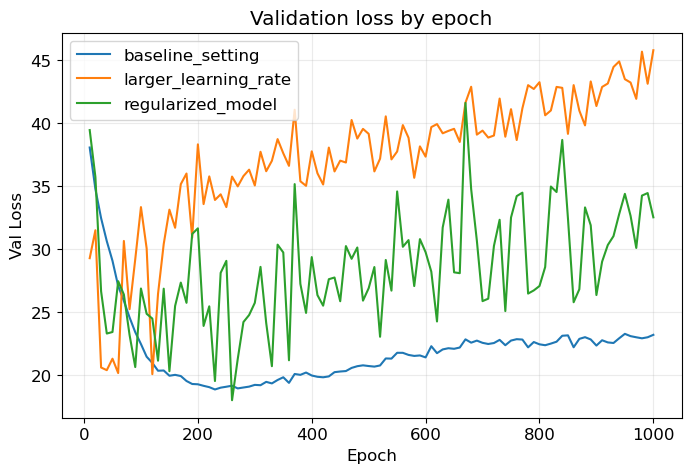

In [8]:
utils.plot_optimizer_histories(
    trial_histories, x_axis="epoch", metric="val_loss",
    title="Validation loss by epoch"
)

### STEP 4 시도 내용 및 해석

본인이 시도한 하이퍼파라미터 튜닝 방법에 대해서 자유롭게 기술해주세요. 

ex: 어떤 하이퍼파라미터를 왜 변경했는지, 해당 변경이 모델의 성능이나 학습 시간에 어떤 영향을 미쳤는지 등

(시도한 방법의 성능이 반드시 좋아야 하는 것은 아닙니다. 다양한 하이퍼파라미터를 직접 변경하며 결과를 비교·분석하는 것이 목표이며, 최종 성능 자체는 채점에 반영되지 않습니다.)

> **시도 내용 및 결과 해석:**  

> STEP 3에서 BGD, SGD, Mini-batch Gradient Descent를 비교한 뒤, 학습 속도와 gradient의 안정성을 함께 고려하여 Mini-batch Gradient Descent를 선택하였다.  
> BGD는 한 epoch마다 전체 데이터를 사용하기 때문에 gradient가 안정적이지만 parameter update 횟수가 적다.  
> 반면 SGD는 데이터 한 개마다 parameter를 업데이트하여 update 횟수가 많고 loss의 변동도 상대적으로 크게 나타날 수 있다.  
> Mini-batch Gradient Descent는 일정 개수의 데이터를 묶어서 사용하므로 두 방법의 중간적인 특성을 가진다.

> 하이퍼파라미터 탐색에서는 learning rate, hidden dimension, batch size, L2 regularization을 변경한 세 가지 조합을 비교하였다.  
> 첫 번째 실험은 hidden dimension을 10, learning rate를 0.001로 설정하여 기준 모델로 사용하였다.  
> 두 번째 실험에서는 hidden dimension을 20으로 늘리고 learning rate를 0.003으로 높여 모델의 표현력과 학습 속도가 어떻게 달라지는지 확인하였다.  
> 세 번째 실험에서는 hidden dimension을 20으로 유지하면서 batch size를 64로 늘리고 L2 regularization을 추가하여 더 안정적인 학습과 과적합 완화 효과가 나타나는지 확인하였다.

> 실험 결과를 비교할 때에는 최종 validation loss와 validation accuracy뿐만 아니라 parameter update 횟수와 실행 시간도 함께 살펴보았다.  
> Learning rate가 큰 설정은 loss가 더 빠르게 감소할 수 있지만, 값이 지나치게 크면 학습 과정이 불안정해질 수 있다.  
> Hidden dimension을 늘리면 모델이 더 복잡한 결정 경계를 학습할 수 있지만 parameter 수와 계산량도 증가한다.  
> 또한 batch size를 크게 설정하면 epoch당 parameter update 횟수가 줄어 실행 시간이 감소할 수 있지만, 작은 batch에서 얻을 수 있는 gradient의 변동성은 줄어든다.  
> L2 regularization을 적용한 모델은 weight가 지나치게 커지는 것을 제한하므로 training loss는 다소 높아질 수 있지만 validation 성능의 안정성에 도움이 될 수 있다.

> 따라서 하나의 성능 지표만으로 모델을 선택하기보다는 validation loss, validation accuracy, 학습 시간, update 횟수를 함께 비교해야 한다는 점을 확인하였다.  
> 이번 실험을 통해 learning rate, hidden dimension, batch size, regularization이 모델의 성능과 학습 효율에 서로 다른 영향을 준다는 것을 확인하였다.